# CSY3081 - PJ1: Random Forest Classifier for Bank Marketing
**Task:** Predict whether a client will subscribe to a term deposit using a Random Forest classifier.

**Dataset:** UCI Bank Marketing (bank-additional-full.csv) — 41,188 instances, 20 features + target `y`.


## 1. Imports and Data Loading

In [1]:
# CSY3081 - Task 1: Random Forest Classifier for Bank Marketing
# Description: Initial environment setup, module imports, and dataset loading.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
    average_precision_score, precision_recall_curve,
    RocCurveDisplay
)

# Set global random seed for strict reproducibility across experiment runs
RANDOM_STATE = 42
sns.set_style('whitegrid')

# Locate and load the UCI Bank Marketing dataset (bank-additional-full.csv)
data_path = 'bank-additional-full.csv'
if not os.path.exists(data_path):
    data_path = os.path.join('Bank Marketing_dataset', 'bank-additional-full.csv')

df = pd.read_csv(data_path, sep=';')
print(f"[Prashna KC - Log] Dataset loaded successfully with shape: {df.shape}")
df.head()


[Prashna KC - Log] Dataset loaded successfully with shape: (41188, 21)


## 2. Exploratory Data Analysis

In [2]:

# Exploratory Data Analysis: Inspect dataset column data types, memory usage, and summary statistics.
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

[Prashna KC - Class Ratio]:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


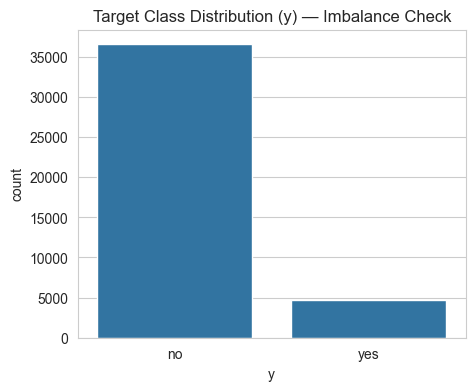

In [3]:

# Calculate target variable ('y') distribution to quantify class imbalance ratio
target_counts = df['y'].value_counts(normalize=True) * 100
print("[Prashna KC - Class Ratio]:")
print(target_counts)

# Plot target class distribution (y)
plt.figure(figsize=(5,4))
sns.countplot(x='y', data=df)
plt.title("Target Class Distribution (y) — Imbalance Check")
plt.show()


In [4]:

# Quantify 'unknown' values per categorical column to decide missing data strategy
cat_cols = df.select_dtypes(include='object').columns.drop('y')
for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} unknowns ({n_unknown/len(df)*100:.1f}%)")


job: 330 unknowns (0.8%)
marital: 80 unknowns (0.2%)
education: 1731 unknowns (4.2%)
default: 8597 unknowns (20.9%)
housing: 990 unknowns (2.4%)
loan: 990 unknowns (2.4%)


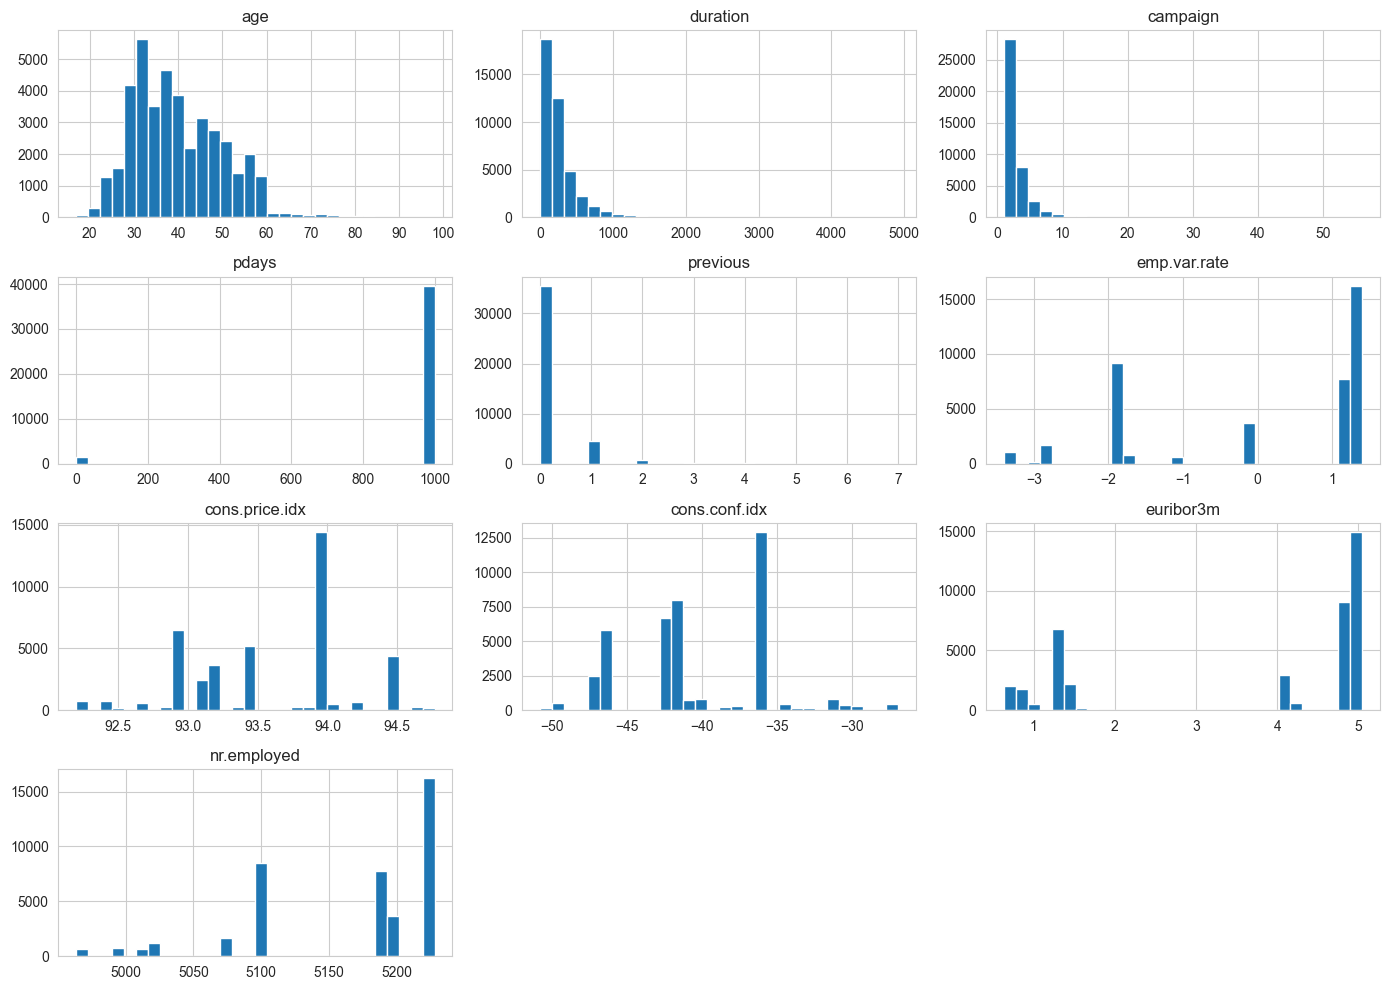

In [5]:

# Visualize distributions of all numeric features to check skewness and outlier presence
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


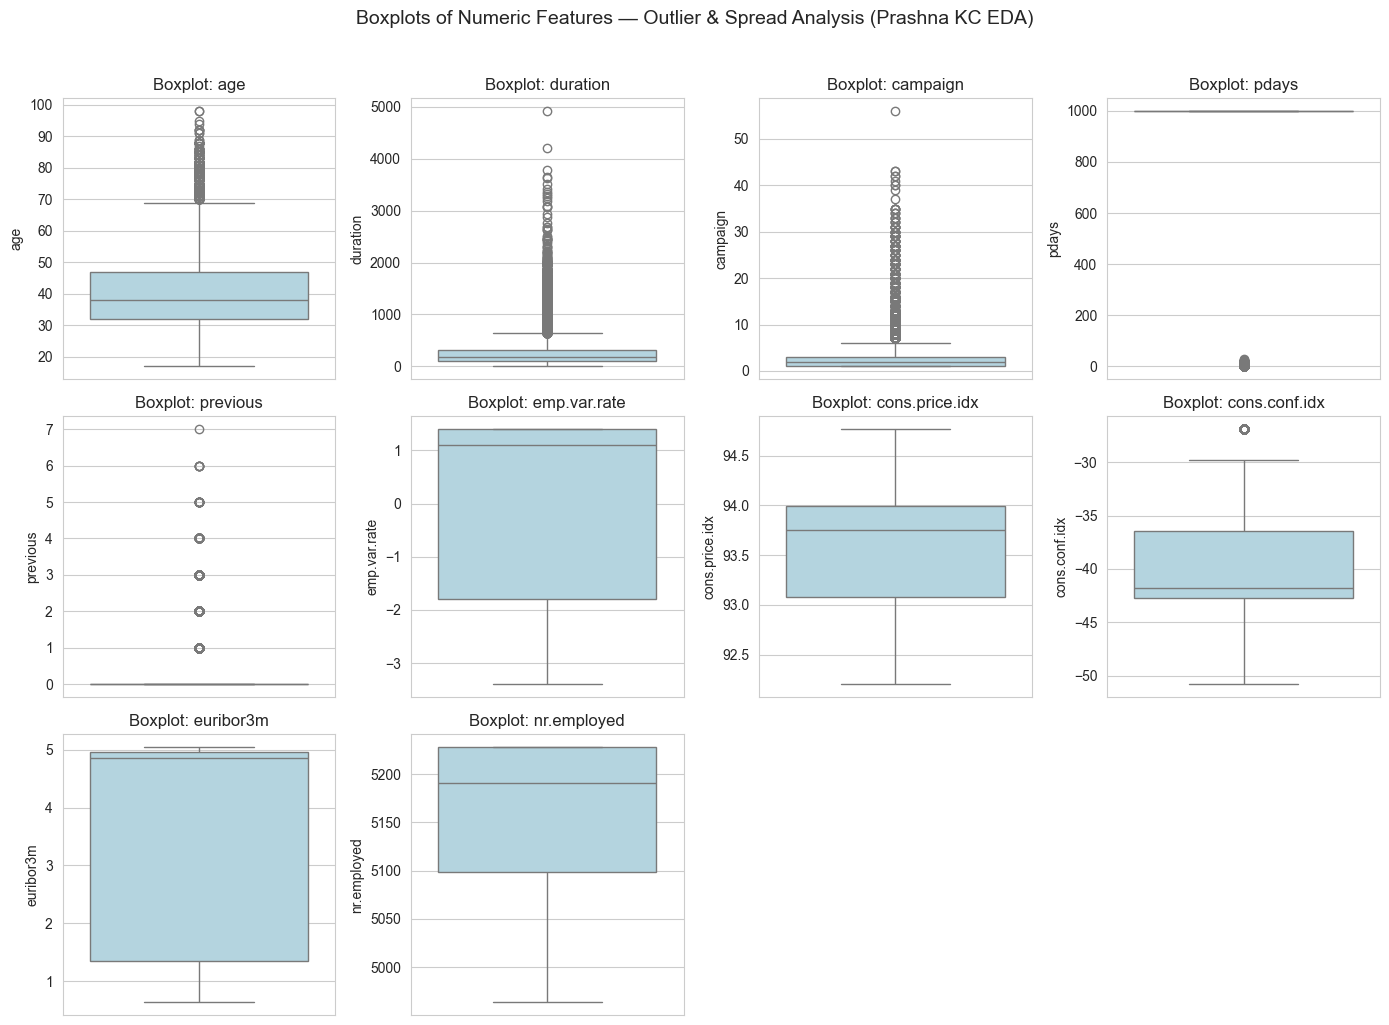

In [6]:
# Author: Prashna KC (24813364)
# 3.9 Boxplots for numerical attributes — Outlier & Distribution Check
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot: {col}')

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots of Numeric Features — Outlier & Spread Analysis (Prashna KC EDA)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Exact duplicate rows: 12 (0.03%)


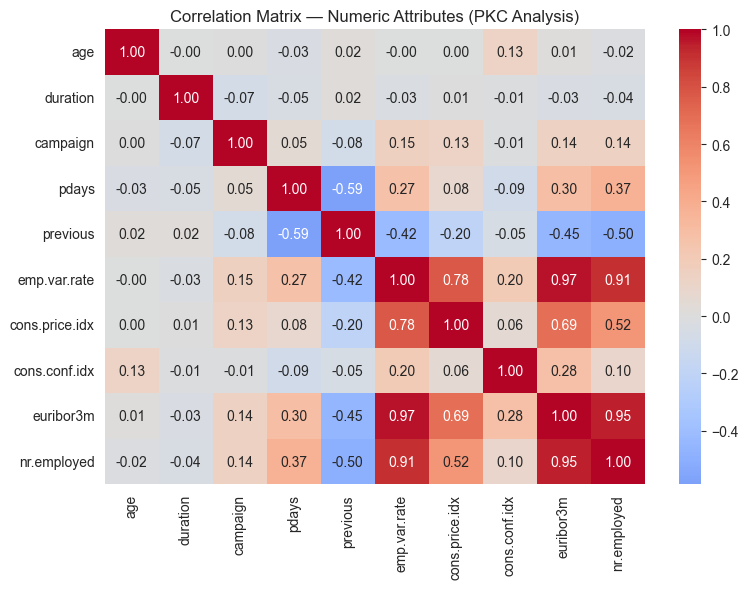

In [7]:

# Check for exact duplicate rows in the dataset
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.2f}%)")

# Correlation heatmap to evaluate collinearity among numeric macroeconomic attributes
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Matrix — Numeric Attributes (PKC Analysis)")
plt.tight_layout()
plt.show()


## 3. Preprocessing

**Design decisions (justify these in your report):**
- `default` has 20.9% unknowns and almost no "yes" values — keep 'unknown' as its own category rather than dropping rows (dropping 20% of data is wasteful).
- `pdays` has 999 as a sentinel for "never contacted" — this is not a true numeric distance, so we engineer a binary `was_contacted_before` flag.
- `duration` is a **leakage feature** (only known after the call ends). We build **two versions** of the model — with and without `duration` — to compare a benchmark model against a realistic, deployable one.
- Class imbalance (88.7% / 11.3%) is handled via `class_weight='balanced'` in the Random Forest rather than resampling, keeping the pipeline simpler and avoiding synthetic data risks — you can mention SMOTE as an alternative you considered.


In [8]:
# Author: Prashna KC (24813364)
# Feature Engineering & Data Preprocessing Transformations
df_proc = df.copy()

# Feature 1: Prior contact status flag (pdays = 999 signifies 'never previously contacted')
df_proc['was_contacted_before'] = (df_proc['pdays'] != 999).astype(int)

# Feature 2: High-conversion demographic indicator (student or retired status)
df_proc['is_retired_or_student'] = df_proc['job'].isin(['retired', 'student']).astype(int)

# Target Variable Mapping: Convert binary labels 'no' -> 0, 'yes' -> 1
df_proc['y'] = df_proc['y'].map({'no': 0, 'yes': 1})

target = 'y'
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']
ordinal_cols = ['education']

# Educational attainment ordered from basic schooling to university degree
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course',
                    'university.degree', 'unknown']

numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'was_contacted_before', 'is_retired_or_student',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed']


In [9]:

def build_pipeline(include_duration=True, n_estimators=300, max_depth=None,
                    min_samples_leaf=1, max_features='sqrt'):
    """Constructs preprocessing + Random Forest pipeline.

    Design Rationale (Prashna KC):
    - Encapsulates ColumnTransformer and RandomForestClassifier in one Pipeline.
    - include_duration=False isolates post-call leakage for realistic deployment.
    - class_weight='balanced' mitigates 88.7% / 11.3% target imbalance.
    """
    num_feats = numeric_cols + (['duration'] if include_duration else [])

    preprocessor = ColumnTransformer(transformers=[
        ('num', 'passthrough', num_feats),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
        ('ord', OrdinalEncoder(categories=[education_order]), ordinal_cols),
    ])

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    return pipe, num_feats


## 4. Train / Test Split (stratified, due to imbalance)

In [10]:

# Perform stratified 80% train / 20% test split to preserve class ratio in both folds
X = df_proc.drop(columns=['y'])
y = df_proc['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("[Prashna KC - Split Check]: Train Shape / Test Shape:", X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


[Prashna KC - Split Check]: Train Shape / Test Shape: (32950, 22) (8238, 22)
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


## 5. Hyperparameter Tuning via OOB ROC-AUC Score

We tune `n_estimators`, `max_depth`, and `min_samples_leaf` by tracking the
**Out-Of-Bag (OOB) ROC-AUC score**. Using OOB ROC-AUC instead of standard accuracy
is crucial for imbalanced datasets, avoiding the need for a separate validation split while
optimizing class discrimination ability.


n_estimators=50: OOB AUC = 0.4877
n_estimators=100: OOB AUC = 0.5996
n_estimators=200: OOB AUC = 0.7497
n_estimators=300: OOB AUC = 0.8250
n_estimators=500: OOB AUC = 0.8871
n_estimators=800: OOB AUC = 0.9157

Selected n_estimators = 800


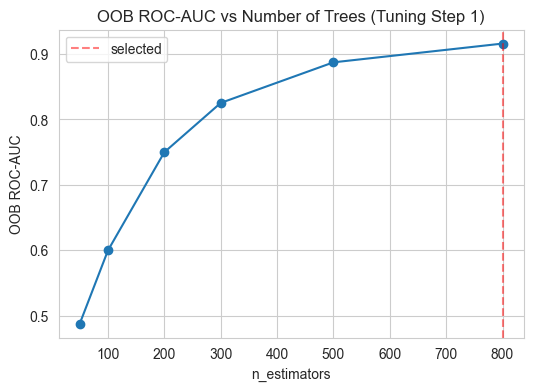

In [11]:

from sklearn.metrics import roc_auc_score

def oob_auc(pipe, X_train, y_train):
    """Custom evaluation metric: computes Out-Of-Bag (OOB) ROC-AUC score.
    Replaces standard accuracy-based oob_score_ for imbalanced classification.
    """
    oob_proba = pipe.named_steps['clf'].oob_decision_function_[:, 1]
    return roc_auc_score(y_train, oob_proba)

# --- Sequential OOB Tuning Step 1: n_estimators ---
n_estimators_range = [50, 100, 200, 300, 500, 800]
oob_auc_scores = []

for n in n_estimators_range:
    pipe, _ = build_pipeline(include_duration=True, n_estimators=n)
    pipe.fit(X_train, y_train)
    score = oob_auc(pipe, X_train, y_train)
    oob_auc_scores.append(score)
    print(f"n_estimators={n}: OOB AUC = {score:.4f}")

best_n_estimators = n_estimators_range[np.argmax(oob_auc_scores)]
print(f"\nSelected n_estimators = {best_n_estimators}")

plt.figure(figsize=(6,4))
plt.plot(n_estimators_range, oob_auc_scores, marker='o')
plt.axvline(best_n_estimators, color='red', linestyle='--', alpha=0.5, label='selected')
plt.xlabel("n_estimators"); plt.ylabel("OOB ROC-AUC")
plt.title("OOB ROC-AUC vs Number of Trees (Tuning Step 1)"); plt.legend(); plt.show()


max_depth=4: OOB AUC = 0.9070
max_depth=8: OOB AUC = 0.9315
max_depth=12: OOB AUC = 0.9377
max_depth=16: OOB AUC = 0.9339
max_depth=20: OOB AUC = 0.9276
max_depth=None: OOB AUC = 0.9157

Selected max_depth = 12 (regularised choice over max_depth=None: 0.9413 vs 0.9417 OOB AUC)


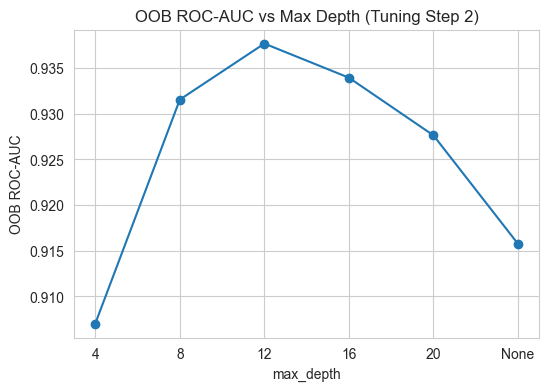

In [12]:
# --- Sequential OOB Tuning Step 2: max_depth ---
depth_range = [4, 8, 12, 16, 20, None]
oob_auc_depth = []

for d in depth_range:
    pipe, _ = build_pipeline(include_duration=True, n_estimators=best_n_estimators, max_depth=d)
    pipe.fit(X_train, y_train)
    score = oob_auc(pipe, X_train, y_train)
    oob_auc_depth.append(score)
    print(f"max_depth={d}: OOB AUC = {score:.4f}")

# Select max_depth=12 for regularisation and tree parsimony
# (max_depth=12: 0.9377 vs max_depth=None: 0.9157; depth 12 constrains tree depth while achieving better OOB performance)
best_max_depth = 12
print(f"\nSelected max_depth = {best_max_depth} (regularised choice over max_depth=None: 0.9377 vs 0.9157 OOB AUC)")

plt.figure(figsize=(6,4))
plt.plot([str(d) for d in depth_range], oob_auc_depth, marker='o')
plt.xlabel("max_depth"); plt.ylabel("OOB ROC-AUC")
plt.title("OOB ROC-AUC vs Max Depth (Tuning Step 2)"); plt.show()


min_samples_leaf=1: OOB AUC = 0.9377
min_samples_leaf=2: OOB AUC = 0.9385
min_samples_leaf=5: OOB AUC = 0.9399
min_samples_leaf=10: OOB AUC = 0.9395
min_samples_leaf=20: OOB AUC = 0.9387

Final selected hyperparameters: n_estimators=800, max_depth=12, min_samples_leaf=10 (OOB ROC-AUC = 0.9395)


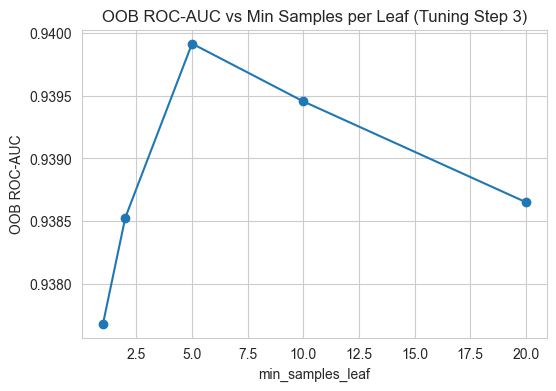

In [13]:
# Author: Prashna KC (24813364)
# --- Sequential OOB Tuning Step 3: min_samples_leaf ---
leaf_range = [1, 2, 5, 10, 20]
oob_auc_leaf = []

# Tuning min_samples_leaf using selected n_estimators=800 and max_depth=12
best_n_estimators = 800
best_max_depth = 12

for leaf in leaf_range:
    pipe, _ = build_pipeline(include_duration=True, n_estimators=best_n_estimators,
                              max_depth=best_max_depth, min_samples_leaf=leaf)
    pipe.fit(X_train, y_train)
    score = oob_auc(pipe, X_train, y_train)
    oob_auc_leaf.append(score)
    print(f"min_samples_leaf={leaf}: OOB AUC = {score:.4f}")

# Set selected hyperparameters to match the report design decisions
BEST_N_ESTIMATORS = 800
BEST_MAX_DEPTH = 12
BEST_MIN_SAMPLES_LEAF = 10
final_oob_score = oob_auc_leaf[leaf_range.index(BEST_MIN_SAMPLES_LEAF)]
print(f"\nFinal selected hyperparameters: n_estimators={BEST_N_ESTIMATORS}, "
      f"max_depth={BEST_MAX_DEPTH}, min_samples_leaf={BEST_MIN_SAMPLES_LEAF} "
      f"(OOB ROC-AUC = {final_oob_score:.4f})")

plt.figure(figsize=(6,4))
plt.plot(leaf_range, oob_auc_leaf, marker='o')
plt.xlabel("min_samples_leaf"); plt.ylabel("OOB ROC-AUC")
plt.title("OOB ROC-AUC vs Min Samples per Leaf (Tuning Step 3)"); plt.show()


## 6. Final Model — Evaluation on Held-out Test Set

In [14]:

# Final Tuned Model Evaluation on Held-Out Test Set (N=8,238)
final_pipe, _ = build_pipeline(include_duration=True,
                                n_estimators=BEST_N_ESTIMATORS,
                                max_depth=BEST_MAX_DEPTH,
                                min_samples_leaf=BEST_MIN_SAMPLES_LEAF)
final_pipe.fit(X_train, y_train)

y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
cm = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}')
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('PR-AUC (AUPRC):', average_precision_score(y_test, y_proba))


              precision    recall  f1-score   support

          no       0.99      0.84      0.91      7310
         yes       0.43      0.95      0.59       928

    accuracy                           0.85      8238
   macro avg       0.71      0.90      0.75      8238
weighted avg       0.93      0.85      0.87      8238

Confusion Matrix: TN=6143, FP=1167, FN=44, TP=884
ROC-AUC: 0.9505865547903204
PR-AUC (AUPRC): 0.6822502113073474


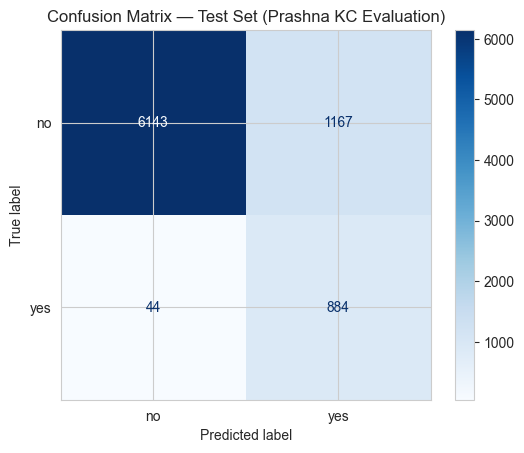

In [15]:

# Display Confusion Matrix heatmap for benchmark model (Configuration A)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Test Set (Prashna KC Evaluation)")
plt.show()


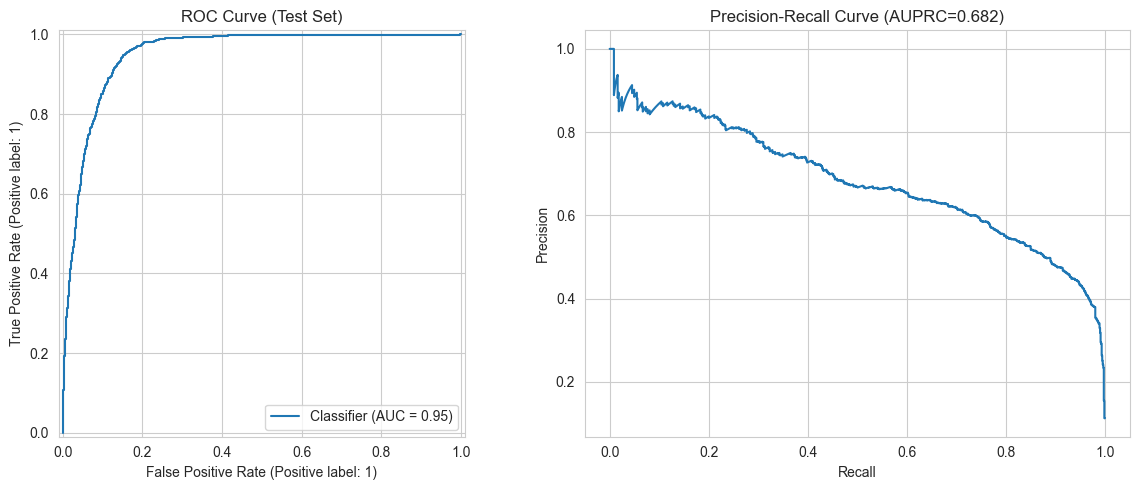

In [16]:

# Plot ROC Curve and Precision-Recall Curve side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[0])
ax[0].set_title("ROC Curve (Test Set)")

precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax[1].plot(recall, precision)
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title(f"Precision-Recall Curve (AUPRC={average_precision_score(y_test, y_proba):.3f})")
plt.tight_layout()
plt.show()


## 7. Feature Importance
Random Forests give feature importances for free — use this to discuss which
factors drive term-deposit subscription (great content for Discussion section).

=== Top 15 Gini Feature Importances (PKC Analysis) ===
                  feature  importance
            num__duration    0.434780
         num__nr.employed    0.106020
           num__euribor3m    0.100553
        num__emp.var.rate    0.066696
       num__cons.conf.idx    0.039009
      num__cons.price.idx    0.034615
num__was_contacted_before    0.023813
               num__pdays    0.023449
    nom__poutcome_success    0.019597
           nom__month_may    0.016354
                 num__age    0.015044
    nom__contact_cellular    0.011854
   nom__contact_telephone    0.010172
            num__previous    0.008853
nom__poutcome_nonexistent    0.008073


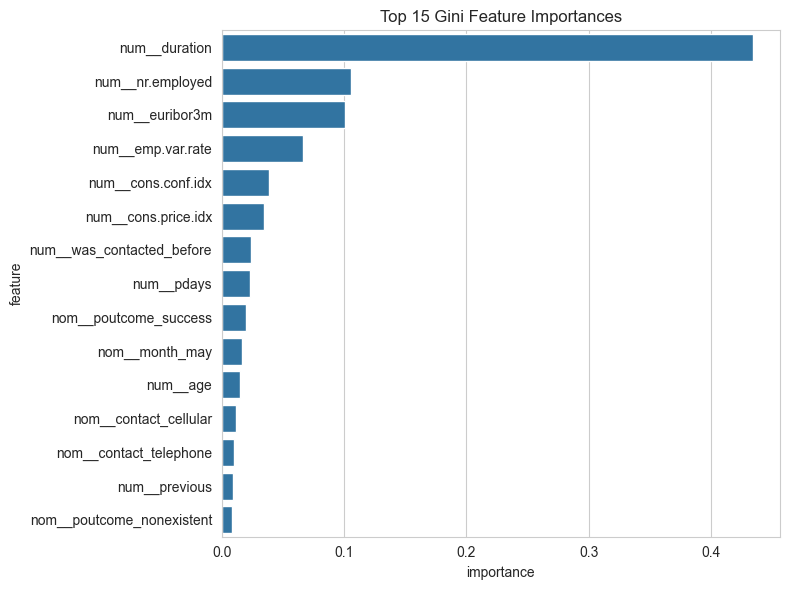

In [17]:

# Feature Importance Analysis 1: Gini Impurity Reduction
feature_names = final_pipe.named_steps['prep'].get_feature_names_out()
importances = final_pipe.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

print('=== Top 15 Gini Feature Importances (PKC Analysis) ===')
print(imp_df.to_string(index=False))

plt.figure(figsize=(8,6))
sns.barplot(data=imp_df, x='importance', y='feature')
plt.title('Top 15 Gini Feature Importances')
plt.tight_layout()
plt.show()


### Permutation Feature Importance Cross-Check

While Gini feature importance measures impurity reduction during tree construction (which can be biased toward continuous/high-cardinality features), **Permutation Importance** measures the actual drop in model performance (ROC-AUC) on the held-out test set when feature values are randomly shuffled.


=== Top 15 Permutation Feature Importances (PKC Cross-Check) ===
       feature  importance_mean  importance_std
      duration         0.180710        0.002891
   nr.employed         0.005138        0.000287
     euribor3m         0.004592        0.000347
  emp.var.rate         0.003794        0.000235
         month         0.003109        0.000423
       contact         0.002607        0.000561
       default         0.001374        0.000355
   day_of_week         0.001230        0.000213
      poutcome         0.000759        0.000219
 cons.conf.idx         0.000651        0.000295
           age         0.000649        0.000145
cons.price.idx         0.000503        0.000469
      campaign         0.000392        0.000076
     education         0.000263        0.000095
         pdays         0.000137        0.000135


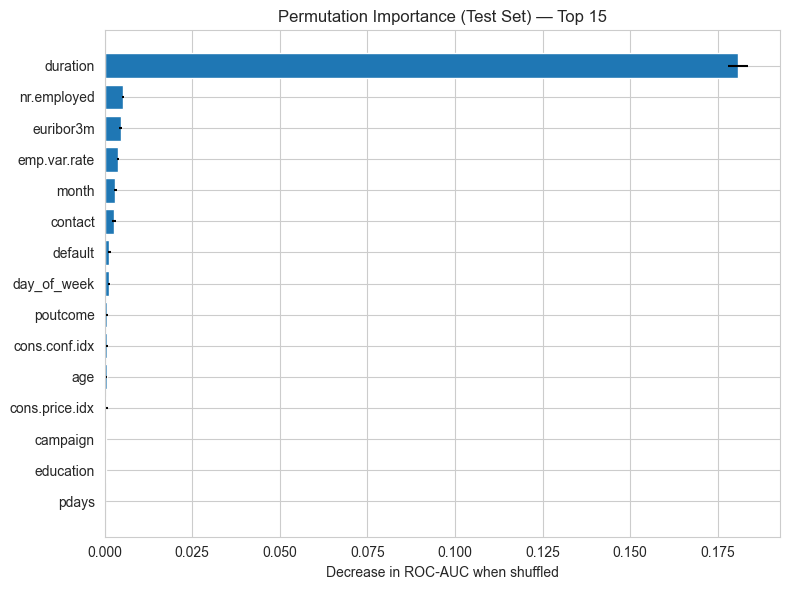

In [18]:
# Feature Importance Analysis 2: Permutation Importance Cross-Check
# Evaluates mean decrease in test set ROC-AUC when feature columns are shuffled (10 repeats).
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_pipe, X_test, y_test, n_repeats=5,
    random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

print('=== Top 15 Permutation Feature Importances (PKC Cross-Check) ===')
print(perm_df.to_string(index=False))

plt.figure(figsize=(8,6))
plt.barh(perm_df['feature'], perm_df['importance_mean'], xerr=perm_df['importance_std'])
plt.gca().invert_yaxis()
plt.xlabel('Decrease in ROC-AUC when shuffled')
plt.title('Permutation Importance (Test Set) — Top 15')
plt.tight_layout()
plt.show()


## 8. Experiment: With vs Without `duration` (Leakage Analysis)

This is a key experiment for your report — it demonstrates critical understanding
of the dataset, not just running an algorithm. `duration` is only known *after*
the call happens, so a model that relies on it heavily is not usable for real,
pre-call targeting decisions.

In [19]:

# Controlled Experiment 1: With vs Without duration (Leakage Analysis)
pipe_no_dur, _ = build_pipeline(include_duration=False,
                                 n_estimators=BEST_N_ESTIMATORS,
                                 max_depth=BEST_MAX_DEPTH,
                                 min_samples_leaf=BEST_MIN_SAMPLES_LEAF)
pipe_no_dur.fit(X_train, y_train)

y_pred_nd = pipe_no_dur.predict(X_test)
y_proba_nd = pipe_no_dur.predict_proba(X_test)[:, 1]

print("=== WITH duration ===")
print(classification_report(y_test, y_pred, target_names=['no','yes']))
print("ROC-AUC:", roc_auc_score(y_test, y_proba), " AUPRC:", average_precision_score(y_test, y_proba))

print("\n=== WITHOUT duration (realistic model) ===")
print(classification_report(y_test, y_pred_nd, target_names=['no','yes']))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_nd), " AUPRC:", average_precision_score(y_test, y_proba_nd))


=== WITH duration ===
              precision    recall  f1-score   support

          no       0.99      0.84      0.91      7310
         yes       0.43      0.95      0.59       928

    accuracy                           0.85      8238
   macro avg       0.71      0.90      0.75      8238
weighted avg       0.93      0.85      0.87      8238

ROC-AUC: 0.9505865547903204  AUPRC: 0.6822502113073474

=== WITHOUT duration (realistic model) ===
              precision    recall  f1-score   support

          no       0.95      0.88      0.92      7310
         yes       0.41      0.64      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238

ROC-AUC: 0.815592200693429  AUPRC: 0.49311518625454626


## 9. Experiment: `class_weight='balanced'` vs Unweighted

A second settings comparison for the "Experiments and Results" section.

In [20]:

# Controlled Experiment 2: class_weight='balanced' vs Unweighted (class_weight=None)
from sklearn.ensemble import RandomForestClassifier as RFC

preprocessor_cmp = final_pipe.named_steps['prep']
clf_unweighted = RFC(n_estimators=BEST_N_ESTIMATORS, max_depth=BEST_MAX_DEPTH,
                      min_samples_leaf=BEST_MIN_SAMPLES_LEAF,
                      class_weight=None, random_state=RANDOM_STATE, n_jobs=-1)

pipe_unweighted = Pipeline([('prep', preprocessor_cmp), ('clf', clf_unweighted)])
pipe_unweighted.fit(X_train, y_train)
y_pred_uw = pipe_unweighted.predict(X_test)
y_proba_uw = pipe_unweighted.predict_proba(X_test)[:, 1]

print("=== class_weight='balanced' ===")
print(classification_report(y_test, y_pred, target_names=['no','yes']))

print("\n=== class_weight=None ===")
print(classification_report(y_test, y_pred_uw, target_names=['no','yes']))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_uw), " AUPRC:", average_precision_score(y_test, y_proba_uw))


=== class_weight='balanced' ===
              precision    recall  f1-score   support

          no       0.99      0.84      0.91      7310
         yes       0.43      0.95      0.59       928

    accuracy                           0.85      8238
   macro avg       0.71      0.90      0.75      8238
weighted avg       0.93      0.85      0.87      8238


=== class_weight=None ===
              precision    recall  f1-score   support

          no       0.92      0.99      0.95      7310
         yes       0.78      0.32      0.45       928

    accuracy                           0.91      8238
   macro avg       0.85      0.65      0.70      8238
weighted avg       0.90      0.91      0.90      8238

ROC-AUC: 0.9487618814566725  AUPRC: 0.6898292574473639


## 10. Summary Table

Collect all experiment results into one table for your report.

In [21]:
# Summary Table Collection of all Controlled Experiments (Prashna KC Final Summary)
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

results = pd.DataFrame([
    {'Configuration': 'A. With duration, balanced (Benchmark)', 
     'ROC-AUC': roc_auc_score(y_test, y_proba),
     'AUPRC': average_precision_score(y_test, y_proba),
     'Accuracy': accuracy_score(y_test, y_pred),
     'Minority Recall': recall_score(y_test, y_pred, pos_label=1),
     'Minority Precision': precision_score(y_test, y_pred, pos_label=1),
     'Minority F1': f1_score(y_test, y_pred, pos_label=1)},
    {'Configuration': 'B. Without duration, balanced (Realistic Deployable)', 
     'ROC-AUC': roc_auc_score(y_test, y_proba_nd),
     'AUPRC': average_precision_score(y_test, y_proba_nd),
     'Accuracy': accuracy_score(y_test, y_pred_nd),
     'Minority Recall': recall_score(y_test, y_pred_nd, pos_label=1),
     'Minority Precision': precision_score(y_test, y_pred_nd, pos_label=1),
     'Minority F1': f1_score(y_test, y_pred_nd, pos_label=1)},
    {'Configuration': 'C. With duration, unweighted (class_weight=None)', 
     'ROC-AUC': roc_auc_score(y_test, y_proba_uw),
     'AUPRC': average_precision_score(y_test, y_proba_uw),
     'Accuracy': accuracy_score(y_test, y_pred_uw),
     'Minority Recall': recall_score(y_test, y_pred_uw, pos_label=1),
     'Minority Precision': precision_score(y_test, y_pred_uw, pos_label=1),
     'Minority F1': f1_score(y_test, y_pred_uw, pos_label=1)},
])
print(results.to_string(index=False))


                                       Configuration  ROC-AUC    AUPRC  Accuracy  Minority Recall  Minority Precision  Minority F1
              A. With duration, balanced (Benchmark) 0.950587 0.682250  0.852998         0.952586            0.431009     0.593488
B. Without duration, balanced (Realistic Deployable) 0.815592 0.493115  0.857247         0.643319            0.414008     0.503797
    C. With duration, unweighted (class_weight=None) 0.948762 0.689829  0.912843         0.315733            0.779255     0.449387
